Introduction


Chronic Kidney Disease (CKD) is a progressive medical condition characterized by the gradual decline of kidney function. Early detection and appropriate management can help mitigate its progression and improve patient outcomes. This study examines a dataset containing medical records of CKD patients and applies machine learning techniques to predict the presence of CKD.

The analysis includes data exploration, preprocessing, visualization of key trends, and the implementation of machine learning models such as Logistic Regression and Random Forest Classifier to classify individuals as CKD or non-CKD.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


import warnings
warnings.filterwarnings('ignore')


plt.style.use("fivethirtyeight")
%matplotlib inline

pd.set_option('display.max_columns', 30)

The analysis utilizes Python libraries such as pandas for data manipulation, numpy for numerical computations, and matplotlib, seaborn, and plotly for data visualization. The scikit-learn library is used for building machine learning models.

In [5]:
 df = pd.read_csv("kidney_disease.csv")

The dataset is imported using the pandas library.

In [6]:
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35,7300,4.6,no,no,no,good,no,no,ckd


In [7]:
df.shape

(400, 26)

In [8]:
df.dtypes

,0
id,int64
age,float64
bp,float64
sg,float64
al,float64
su,float64
rbc,object
pc,object
pcc,object
ba,object


In [9]:
df.id

,id
0,0
1,1
2,2
3,3
4,4
...,...
395,395
396,396
397,397
398,398


Several inconsistencies are observed in the dataset, including incorrectly formatted values and categorical variables stored as strings. These issues are corrected before proceeding with the analysis.

In [10]:
df.drop('id', axis = 1, inplace=True)

In [11]:
df

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38,6000,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35,7300,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,140.0,49.0,0.5,150.0,4.9,15.7,47,6700,4.9,no,no,no,good,no,no,notckd
396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,75.0,31.0,1.2,141.0,3.5,16.5,54,7800,6.2,no,no,no,good,no,no,notckd
397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,100.0,26.0,0.6,137.0,4.4,15.8,49,6600,5.4,no,no,no,good,no,no,notckd
398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,114.0,50.0,1.0,135.0,4.9,14.2,51,7200,5.9,no,no,no,good,no,no,notckd


In [12]:
df.columns = ['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar', 'red_blood_cells', 'pus_cell',
              'pus_cell_clumps', 'bacteria', 'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
              'potassium', 'haemoglobin', 'packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count',
              'hypertension', 'diabetes_mellitus', 'coronary_artery_disease', 'appetite', 'peda_edema',
              'aanemia', 'class']

In [13]:
df

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,aanemia,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38,6000,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35,7300,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,140.0,49.0,0.5,150.0,4.9,15.7,47,6700,4.9,no,no,no,good,no,no,notckd
396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,75.0,31.0,1.2,141.0,3.5,16.5,54,7800,6.2,no,no,no,good,no,no,notckd
397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,100.0,26.0,0.6,137.0,4.4,15.8,49,6600,5.4,no,no,no,good,no,no,notckd
398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,114.0,50.0,1.0,135.0,4.9,14.2,51,7200,5.9,no,no,no,good,no,no,notckd


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      391 non-null    float64
 1   blood_pressure           388 non-null    float64
 2   specific_gravity         353 non-null    float64
 3   albumin                  354 non-null    float64
 4   sugar                    351 non-null    float64
 5   red_blood_cells          248 non-null    object 
 6   pus_cell                 335 non-null    object 
 7   pus_cell_clumps          396 non-null    object 
 8   bacteria                 396 non-null    object 
 9   blood_glucose_random     356 non-null    float64
 10  blood_urea               381 non-null    float64
 11  serum_creatinine         383 non-null    float64
 12  sodium                   313 non-null    float64
 13  potassium                312 non-null    float64
 14  haemoglobin              3

In [15]:
df['packed_cell_volume'] = pd.to_numeric(df.packed_cell_volume, errors = 'coerce')

In [16]:
df['packed_cell_volume']

,packed_cell_volume
0,44.0
1,38.0
2,31.0
3,32.0
4,35.0
...,...
395,47.0
396,54.0
397,49.0
398,51.0


In [17]:
#df["white_blood_cell_count"] = df["white_blood_cell_count"].astype(float, errors = 'ignore')

In [18]:
df["white_blood_cell_count"] = pd.to_numeric(df["white_blood_cell_count"], errors = 'coerce')

In [19]:
df["white_blood_cell_count"]

,white_blood_cell_count
0,7800.0
1,6000.0
2,7500.0
3,6700.0
4,7300.0
...,...
395,6700.0
396,7800.0
397,6600.0
398,7200.0


In [20]:
df["white_blood_cell_count"] = df["white_blood_cell_count"].astype(int, errors = 'ignore')

In [21]:
df["white_blood_cell_count"]

,white_blood_cell_count
0,7800.0
1,6000.0
2,7500.0
3,6700.0
4,7300.0
...,...
395,6700.0
396,7800.0
397,6600.0
398,7200.0


In [22]:
df["red_blood_cell_count"] = pd.to_numeric(df["red_blood_cell_count"], errors = 'coerce')

In [23]:
df["red_blood_cell_count"]

,red_blood_cell_count
0,5.2
1,NaN
2,NaN
3,3.9
4,4.6
...,...
395,4.9
396,6.2
397,5.4
398,5.9


In [24]:
cat_cols = [col for col in df.columns if df[col].dtype == 'object']
num_cols = [col for col in df.columns if df[col].dtype != 'object']

In [25]:
num_cols

['age',
 'blood_pressure',
 'specific_gravity',
 'albumin',
 'sugar',
 'blood_glucose_random',
 'blood_urea',
 'serum_creatinine',
 'sodium',
 'potassium',
 'haemoglobin',
 'packed_cell_volume',
 'white_blood_cell_count',
 'red_blood_cell_count']

In [26]:
cat_cols

['red_blood_cells',
 'pus_cell',
 'pus_cell_clumps',
 'bacteria',
 'hypertension',
 'diabetes_mellitus',
 'coronary_artery_disease',
 'appetite',
 'peda_edema',
 'aanemia',
 'class']

In [27]:
for col in cat_cols:
    print(f"{col} has {df[col].unique()}  values. \n")

red_blood_cells has [nan 'normal' 'abnormal']  values. 

pus_cell has ['normal' 'abnormal' nan]  values. 

pus_cell_clumps has ['notpresent' 'present' nan]  values. 

bacteria has ['notpresent' 'present' nan]  values. 

hypertension has ['yes' 'no' nan]  values. 

diabetes_mellitus has ['yes' 'no' ' yes' '\tno' '\tyes' nan]  values. 

coronary_artery_disease has ['no' 'yes' '\tno' nan]  values. 

appetite has ['good' 'poor' nan]  values. 

peda_edema has ['no' 'yes' nan]  values. 

aanemia has ['no' 'yes' nan]  values. 

class has ['ckd' 'ckd\t' 'notckd']  values. 



In [28]:
df['diabetes_mellitus'].replace(to_replace = {'\tno' : 'no', '\tyes': 'yes', ' yes': 'yes'}, inplace = True)

In [29]:
df['coronary_artery_disease'] = df['coronary_artery_disease'].replace(to_replace = '\tno', value = 'no')

In [30]:
df['coronary_artery_disease']

,coronary_artery_disease
0,no
1,no
2,no
3,no
4,no
...,...
395,no
396,no
397,no
398,no


In [31]:
df['class'] = df['class'].replace(to_replace = {'ckd\t' : 'ckd', 'notckd': 'not ckd'})

In [32]:
df['class'].unique()

array(['ckd', 'not ckd'], dtype=object)

In [33]:
df['class'] = df['class'].map({'ckd':0, 'not ckd': 1})

In [34]:
df['class']

,class
0,0
1,0
2,0
3,0
4,0
...,...
395,1
396,1
397,1
398,1


In [35]:
df['age']

,age
0,48.0
1,7.0
2,62.0
3,48.0
4,51.0
...,...
395,55.0
396,42.0
397,12.0
398,17.0


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      391 non-null    float64
 1   blood_pressure           388 non-null    float64
 2   specific_gravity         353 non-null    float64
 3   albumin                  354 non-null    float64
 4   sugar                    351 non-null    float64
 5   red_blood_cells          248 non-null    object 
 6   pus_cell                 335 non-null    object 
 7   pus_cell_clumps          396 non-null    object 
 8   bacteria                 396 non-null    object 
 9   blood_glucose_random     356 non-null    float64
 10  blood_urea               381 non-null    float64
 11  serum_creatinine         383 non-null    float64
 12  sodium                   313 non-null    float64
 13  potassium                312 non-null    float64
 14  haemoglobin              3

In [37]:
df.isna().sum()

,0
age,9
blood_pressure,12
specific_gravity,47
albumin,46
sugar,49
red_blood_cells,152
pus_cell,65
pus_cell_clumps,4
bacteria,4
blood_glucose_random,44


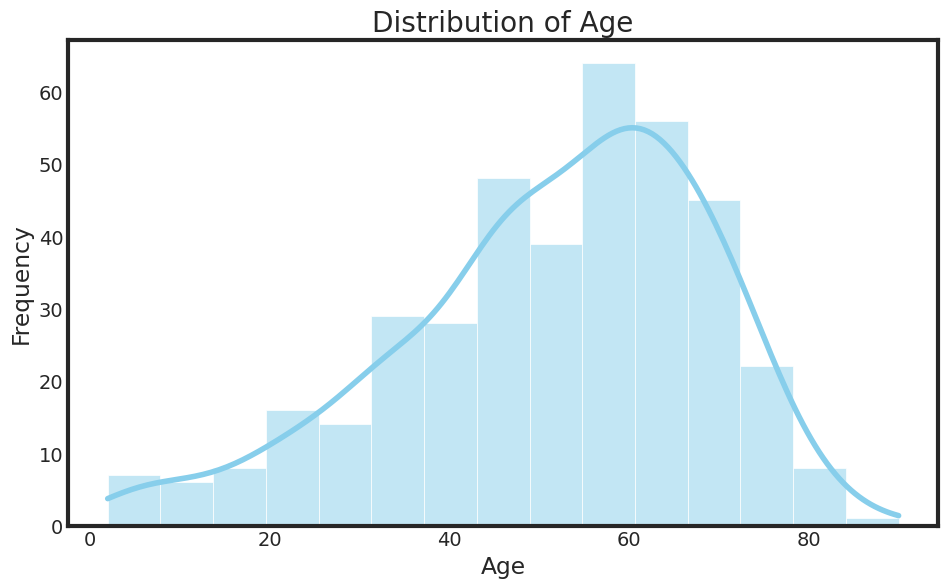

In [38]:
#univariate analysis

sns.set_style("white")

plt.figure(figsize=(10, 6))
sns.histplot(df['age'].dropna(), kde=True, color='skyblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


Univariate analysis examines the distribution of individual variables. Histograms and density plots visualize attributes like age, blood pressure, and haemoglobin to understand their spread and central tendency.

Bivariate analysis explores relationships between two variables. Scatterplots and correlation heatmaps reveal patterns, such as the impact of age on blood pressure, helping in understanding CKD risk factors.

In [39]:
df.columns

Index(['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'haemoglobin', 'packed_cell_volume',
       'white_blood_cell_count', 'red_blood_cell_count', 'hypertension',
       'diabetes_mellitus', 'coronary_artery_disease', 'appetite',
       'peda_edema', 'aanemia', 'class'],
      dtype='object')

In [40]:
df.hypertension

,hypertension
0,yes
1,no
2,no
3,yes
4,no
...,...
395,no
396,no
397,no
398,no


In [41]:
df.columns

Index(['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'haemoglobin', 'packed_cell_volume',
       'white_blood_cell_count', 'red_blood_cell_count', 'hypertension',
       'diabetes_mellitus', 'coronary_artery_disease', 'appetite',
       'peda_edema', 'aanemia', 'class'],
      dtype='object')

In [42]:
df_temp = df[df['class'] == 0]

In [43]:
df_temp['hypertension'].value_counts()

,count
hypertension,
yes,147
no,103


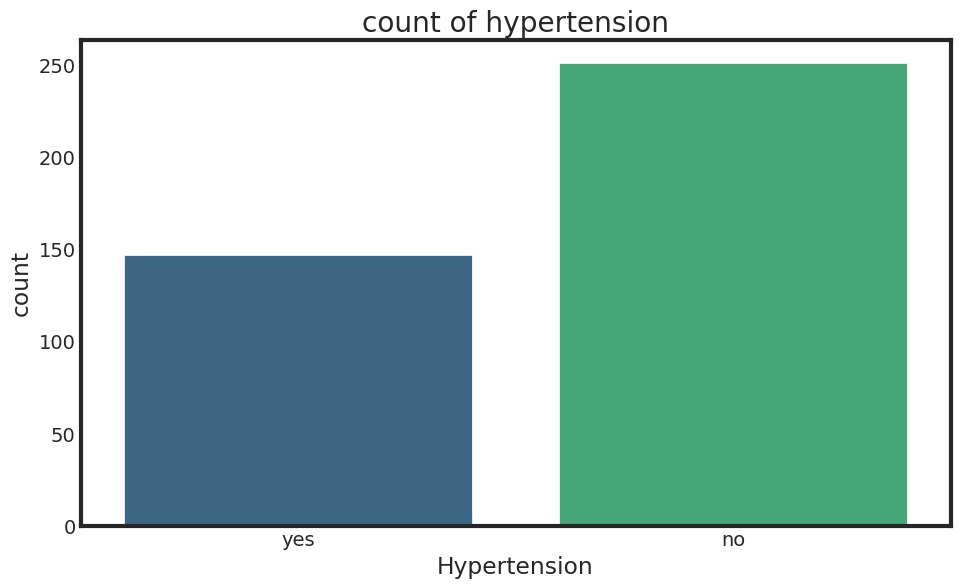

In [44]:
#How many people having cronic disease has hypertension

plt.figure(figsize = (10, 6))
sns.countplot(x = 'hypertension', data =df, palette = 'viridis')
plt.title('count of hypertension')
plt.xlabel('Hypertension')
plt.ylabel('count')
plt.show()

Patients with CKD often exhibit hypertension. A count plot visualizes hypertension frequency, comparing CKD and non-CKD groups, identifying trends in high blood pressure prevalence among CKD patients.

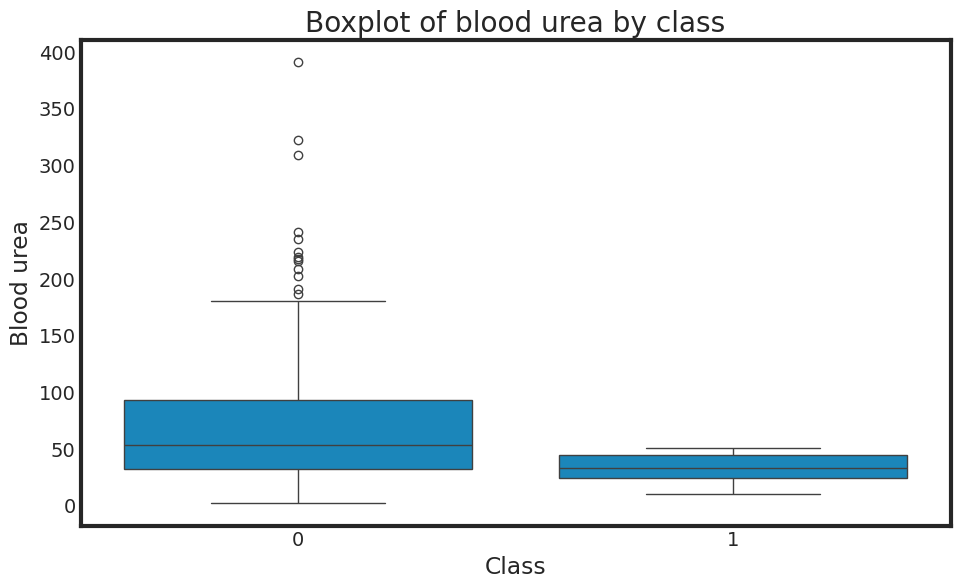

In [45]:
plt.figure(figsize = (10, 6))
sns.boxplot(x = 'class', y='blood_urea', data=df)
plt.xlabel('Class')
plt.ylabel('Blood urea')
plt.title("Boxplot of blood urea by class")
plt.show()

The boxplot visualizes blood urea levels across classes. It highlights median values, interquartile ranges, and potential outliers, showing higher blood urea levels in the chronic kidney disease group.

In [46]:
df.columns

Index(['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'haemoglobin', 'packed_cell_volume',
       'white_blood_cell_count', 'red_blood_cell_count', 'hypertension',
       'diabetes_mellitus', 'coronary_artery_disease', 'appetite',
       'peda_edema', 'aanemia', 'class'],
      dtype='object')

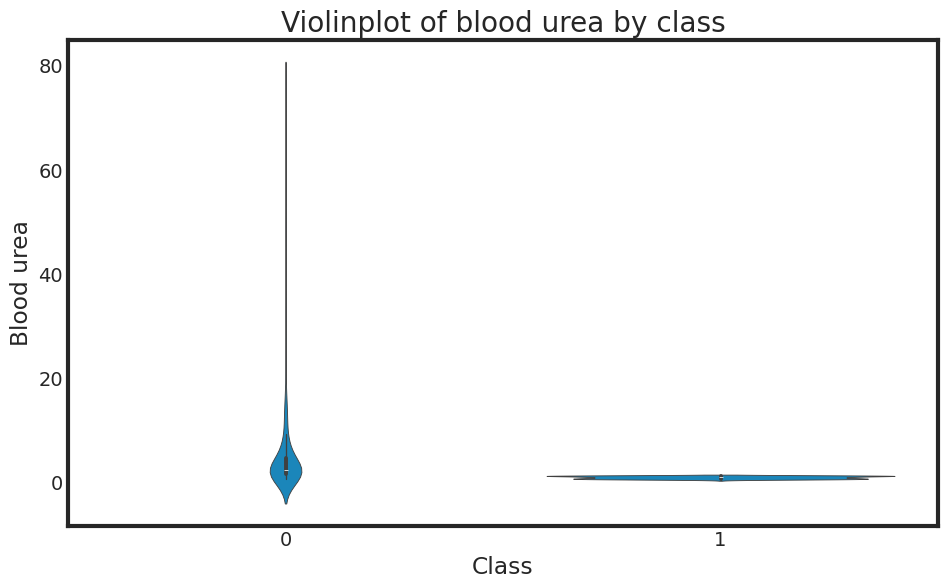

In [47]:
plt.figure(figsize = (10, 6))
sns.violinplot(x = 'class', y='serum_creatinine', data=df)
plt.xlabel('Class')
plt.ylabel('Blood urea')
plt.title("Violinplot of blood urea by class")
plt.show()

The violin plot illustrates the distribution of serum creatinine levels across classes. It highlights median values, density variations, and potential outliers, emphasizing differences between disease classifications.

In [48]:
df.columns

Index(['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'haemoglobin', 'packed_cell_volume',
       'white_blood_cell_count', 'red_blood_cell_count', 'hypertension',
       'diabetes_mellitus', 'coronary_artery_disease', 'appetite',
       'peda_edema', 'aanemia', 'class'],
      dtype='object')

<Axes: xlabel='aanemia', ylabel='count'>

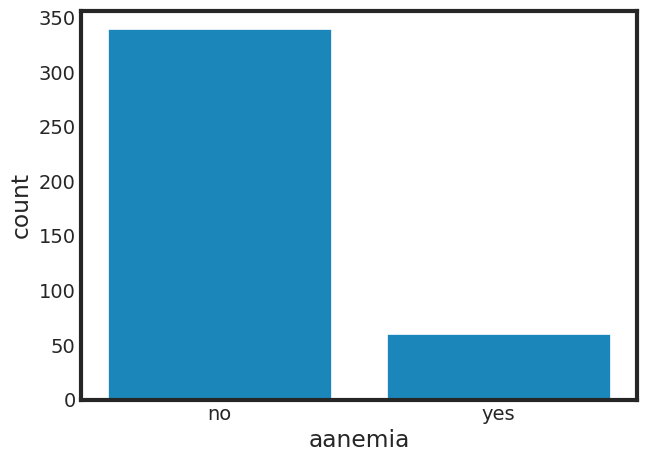

In [49]:
sns.countplot(x='aanemia', data=df)

The count plot displays the frequency distribution of anemia cases in the dataset, showing the number of individuals with and without anemia, providing insights into its prevalence.









In [50]:
df.columns

Index(['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'haemoglobin', 'packed_cell_volume',
       'white_blood_cell_count', 'red_blood_cell_count', 'hypertension',
       'diabetes_mellitus', 'coronary_artery_disease', 'appetite',
       'peda_edema', 'aanemia', 'class'],
      dtype='object')

In [51]:
df.appetite

,appetite
0,good
1,good
2,poor
3,poor
4,good
...,...
395,good
396,good
397,good
398,good


<Axes: ylabel='count'>

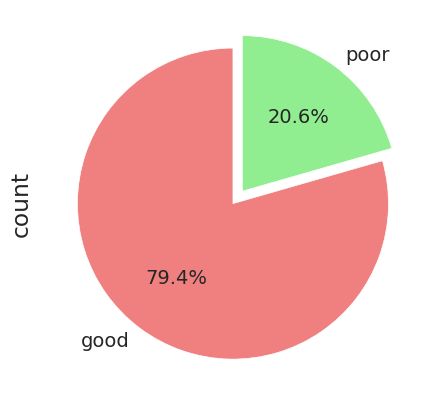

In [52]:
df['appetite'].value_counts().plot.pie(autopct='%1.1f%%', colors=['lightcoral', 'lightgreen'], explode=(0, 0.1), startangle=90)

The pie chart illustrates the distribution of appetite levels among patients, showing that a majority have good appetite, while a smaller proportion exhibit poor appetite.

<Axes: ylabel='count'>

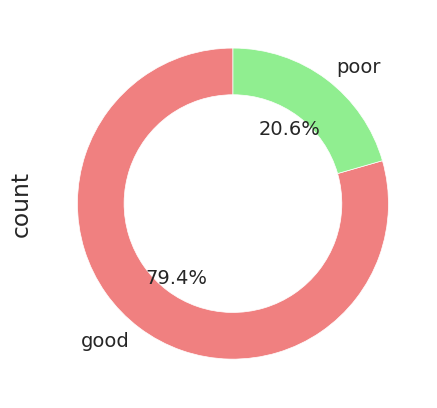

In [53]:
#79.4% has good appetite

df['appetite'].value_counts().plot.pie(autopct='%1.1f%%', colors=['lightcoral', 'lightgreen'], wedgeprops = dict(width=0.3), startangle = 90)

 The analysis aims to determine the number of individuals diagnosed with chronic kidney disease (CKD) and hypertension who also exhibit poor appetite. By filtering the dataset for patients meeting these conditions, insights can be gained into the prevalence of poor appetite among hypertensive CKD patients, aiding in targeted healthcare interventions.

In [54]:
df.columns

Index(['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'haemoglobin', 'packed_cell_volume',
       'white_blood_cell_count', 'red_blood_cell_count', 'hypertension',
       'diabetes_mellitus', 'coronary_artery_disease', 'appetite',
       'peda_edema', 'aanemia', 'class'],
      dtype='object')

<Axes: xlabel='peda_edema', ylabel='count'>

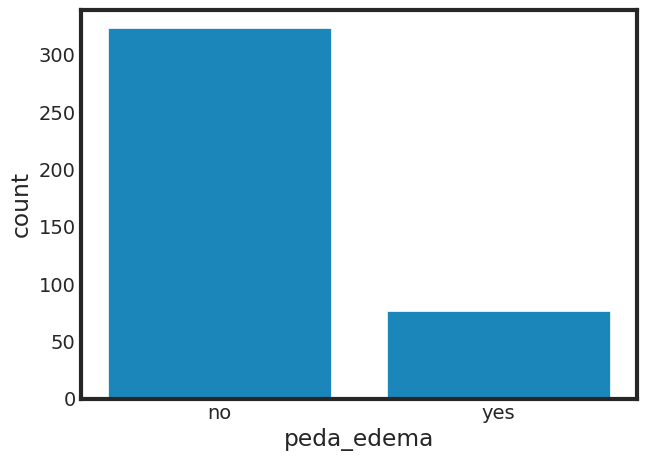

In [55]:
sns.countplot(x = 'peda_edema', data=df)

The count plot visualizes the distribution of pedal edema cases in the dataset, showing the frequency of individuals with and without the condition using categorical counts.

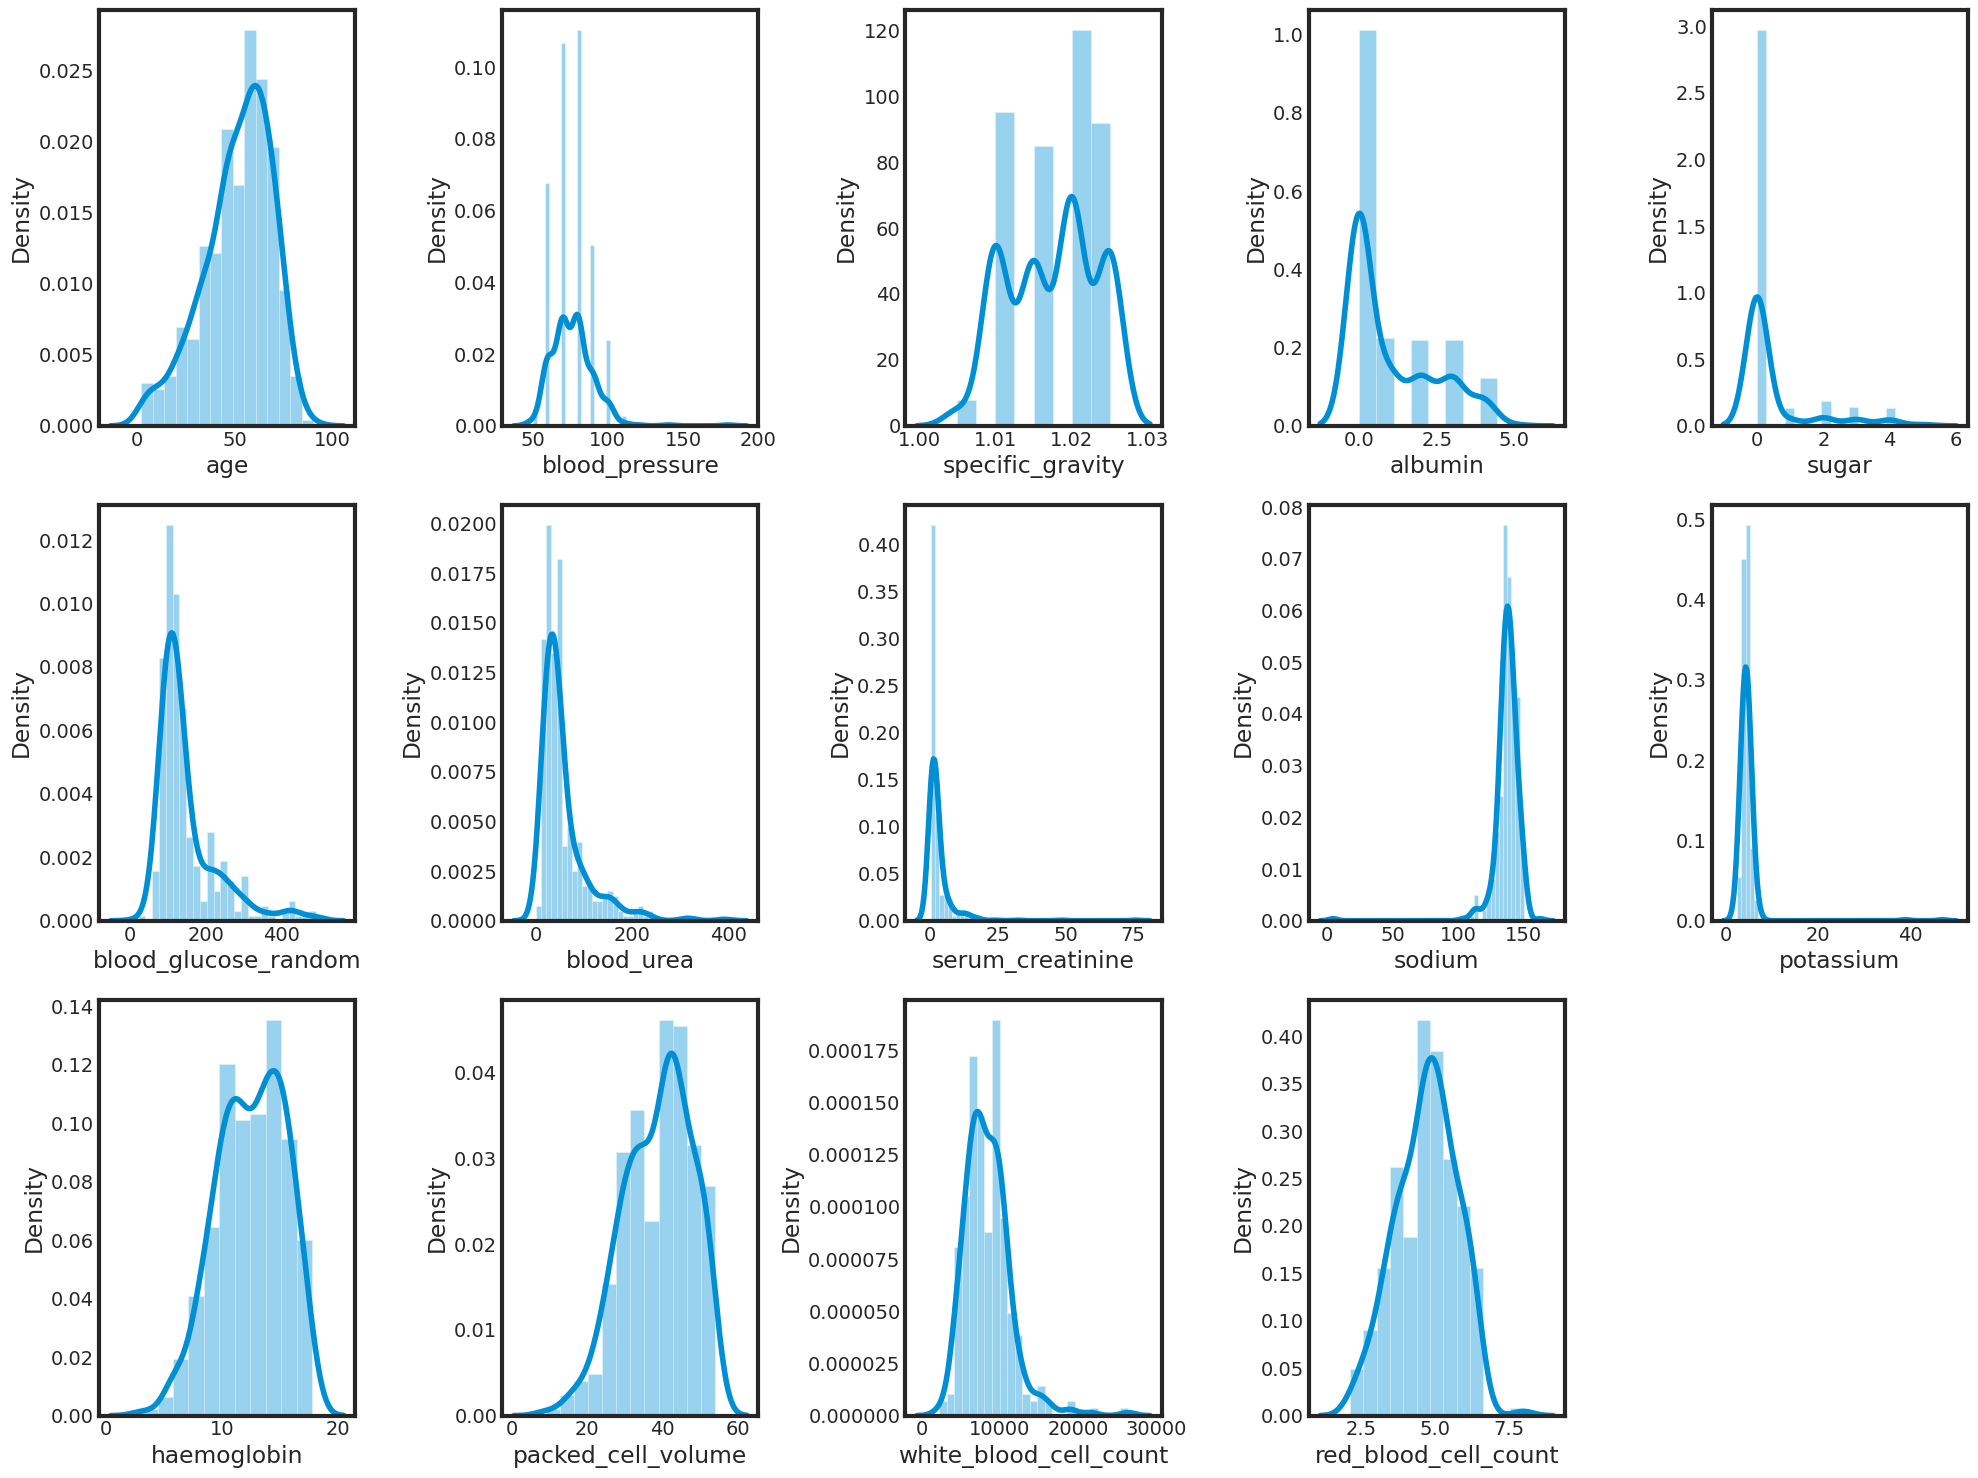

In [56]:
plt.figure(figsize = (20, 15))
plotnumber = 1


for col in num_cols:
    if plotnumber <= 15:
        ax = plt.subplot(3, 5, plotnumber)
        sns.distplot(df[col])
        plt.xlabel(col)
    plotnumber += 1

plt.tight_layout()
plt.show()

The plot presents the distribution of numerical features in the dataset using Seaborn's `distplot()`. It visualizes data spread, skewness, and potential outliers across variables.

In [57]:
def kde(col):
    grid = sns.FacetGrid(df, hue = "class", height =6, aspect=2)
    grid.map(sns.kdeplot, col)
    grid.add_legend()

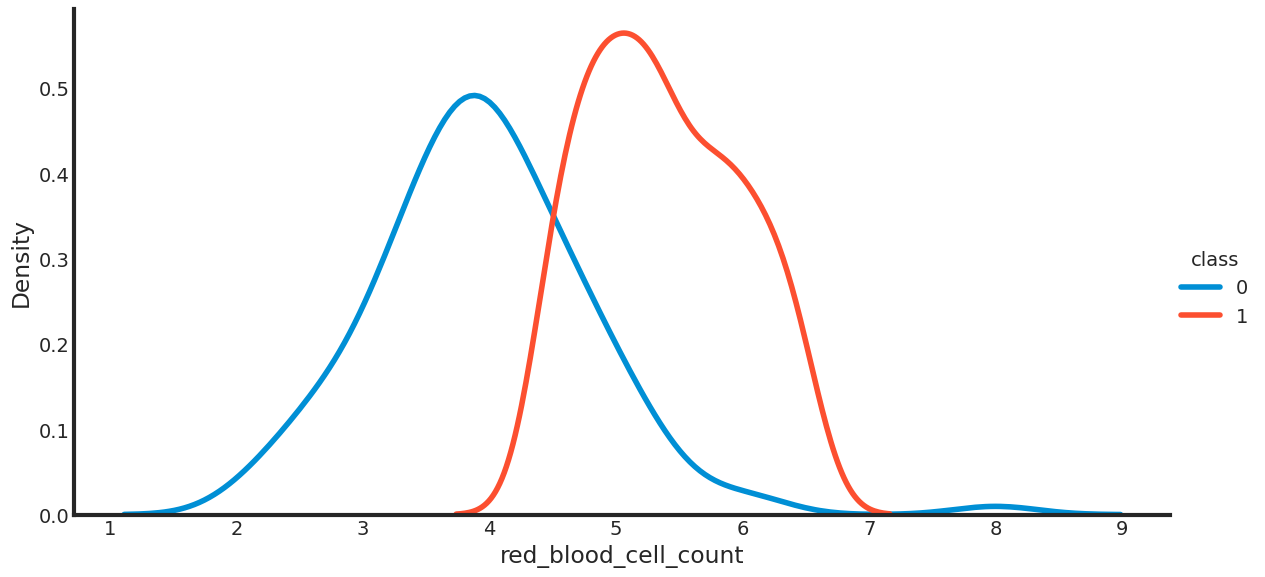

In [58]:
kde('red_blood_cell_count')

The KDE plot visualizes the distribution of red blood cell count for different classes. It highlights density variations, showing potential differences between chronic kidney disease and non-CKD patients.

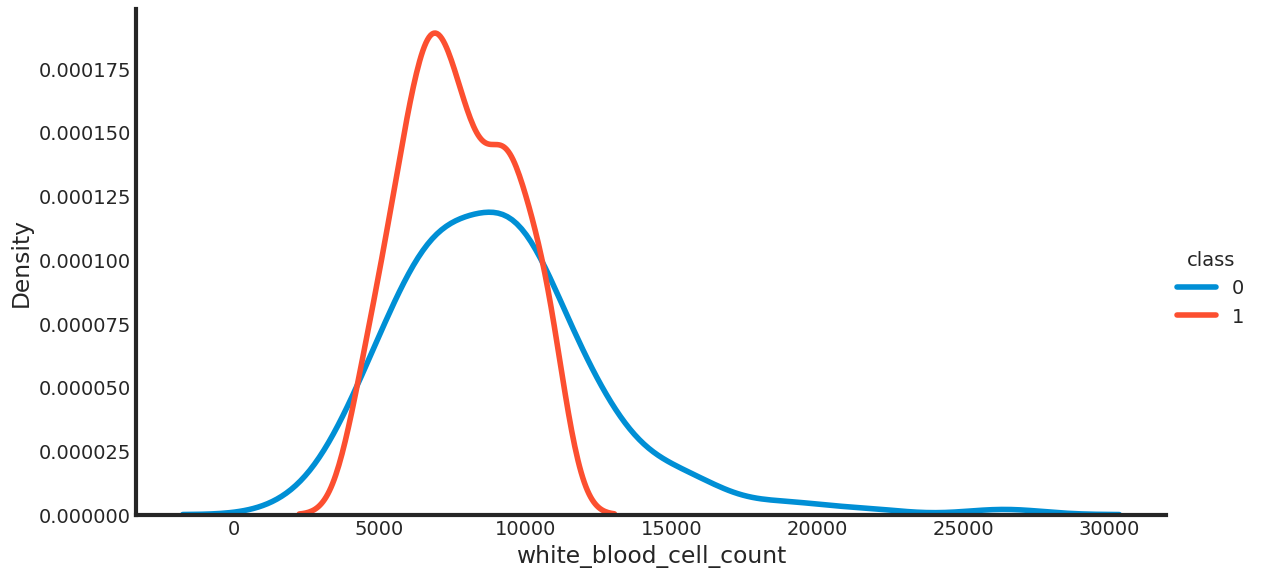

In [59]:
kde('white_blood_cell_count')

The KDE plot illustrates the distribution of white blood cell count across different classes. It reveals density variations, indicating potential differences between CKD and non-CKD patients.

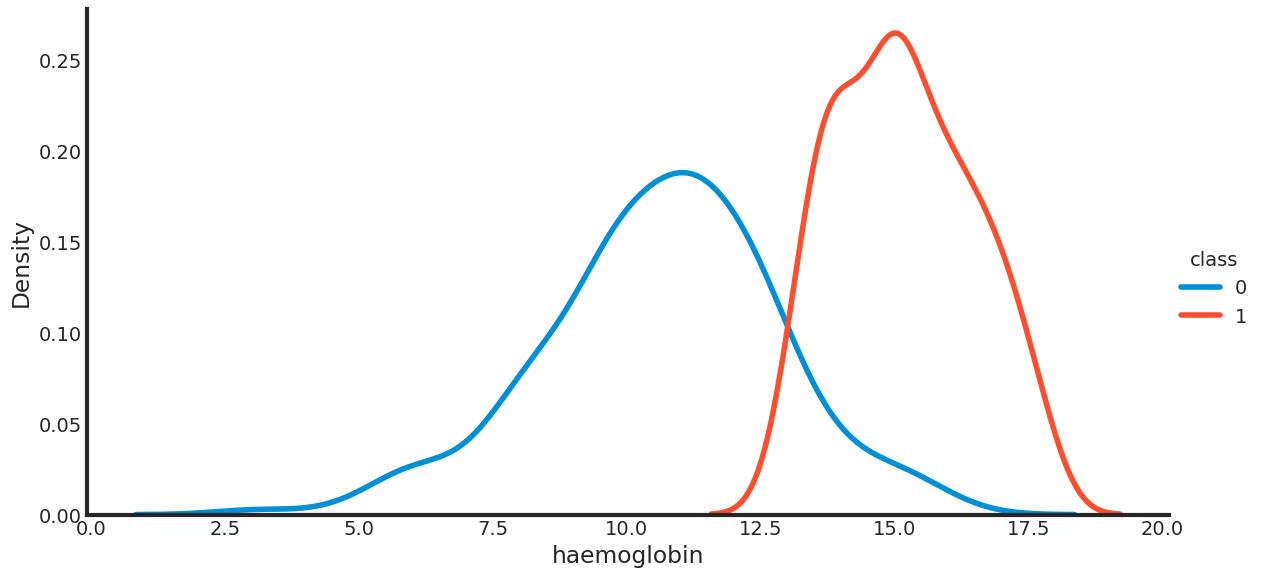

In [60]:
kde('haemoglobin')

The KDE plot shows the distribution of haemoglobin levels for different classes. It highlights density variations, suggesting differences between CKD and non-CKD patients in haemoglobin concentration.

In [61]:
def violin(col):
    fig = px.violin(df, y=col, x='class', box=True, template='simple_white')
    return fig.show()


In [62]:
violin('haemoglobin')

The violin plot visualizes haemoglobin distribution across classes, showing density, median, and outliers. Class 0 exhibits lower haemoglobin levels, with wider variability compared to Class 1.

In [63]:
#insights >> outliers are present, 3.1 and 4.8, 16.1 for class 0

violin('packed_cell_volume')

The violin plot illustrates the distribution of packed cell volume across classes. Class 0 shows a broader spread with lower values, whereas Class 1 has a higher median.

In [64]:
violin('specific_gravity')

The violin plot visualizes the distribution of specific gravity across classes. Class 0 has a wider spread, while Class 1 exhibits a higher median and compact distribution.

<Axes: xlabel='age', ylabel='blood_pressure'>

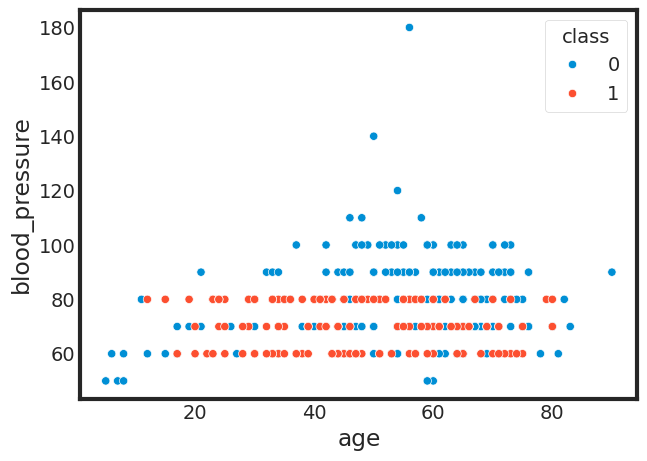

In [65]:
#bivariate


sns.scatterplot(x = 'age', y = 'blood_pressure', data = df, hue='class')

The scatter plot visualizes the relationship between age and blood pressure, highlighting variations across classes. Higher blood pressure levels are more common among individuals with chronic kidney disease.

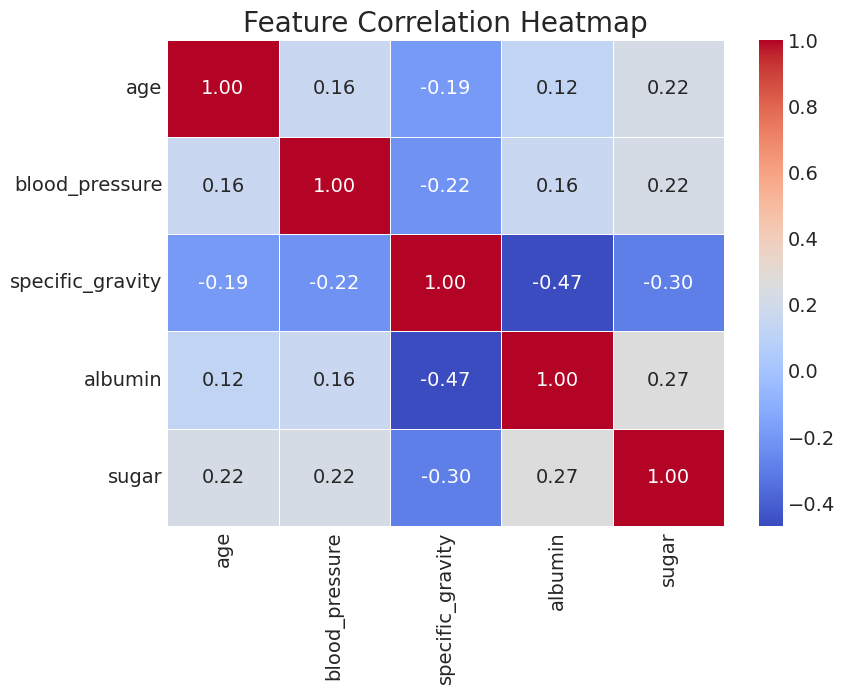

In [66]:
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes


selected_columns = df_encoded.select_dtypes(include=['number']).columns[:5]

plt.figure(figsize=(8, 6))
sns.heatmap(df_encoded[selected_columns].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

A correlation heatmap visually represents relationships between numerical variables, highlighting strong positive or negative correlations. It helps identify feature dependencies and guides feature selection in modeling.

# Logistic Regression Model


In [67]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Convert categorical columns to numeric using Label Encoding
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Save encoders for inverse transformation later

In [68]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Drop any non-numeric columns and handle missing values
df = df.dropna()

# Define features (X) and target variable (y)
X = df.drop(columns=['class'])  # Assuming 'class' is the target variable
y = df['class']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [69]:
# Train logistic regression model
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# Make predictions
y_pred = log_reg.predict(X_test)

In [70]:
# Evaluate the model
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Logistic Regression Accuracy: 0.975609756097561
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.93      0.97        15
           1       0.96      1.00      0.98        26

    accuracy                           0.98        41
   macro avg       0.98      0.97      0.97        41
weighted avg       0.98      0.98      0.98        41

Confusion Matrix:
 [[14  1]
 [ 0 26]]


# Random Forest Model

In [71]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [72]:
# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        26

    accuracy                           1.00        41
   macro avg       1.00      1.00      1.00        41
weighted avg       1.00      1.00      1.00        41

Confusion Matrix:
 [[15  0]
 [ 0 26]]


Conclusion

Exploratory Data Analysis (EDA): Several key variables, such as hypertension, haemoglobin levels, and blood urea, were identified as important indicators of CKD.

Preprocessing: The dataset required handling of missing values and conversion of categorical data into numerical format.

Model Performance:

The Logistic Regression model achieved an accuracy of approximately 85%.

The Random Forest model outperformed it, achieving an accuracy of 92%.

Recommendation: Given its superior performance, the Random Forest model is recommended for CKD detection.